In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
uploaded = files.upload()
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d mohamad1dehqani/persian-spam-email
!unzip persian-spam-email.zip

Saving kaggle (1).json to kaggle (1).json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/mohamad1dehqani/persian-spam-email
License(s): unknown
  0% 0.00/836k [00:00<?, ?B/s]
100% 836k/836k [00:00<00:00, 89.7MB/s]
Archive:  persian-spam-email.zip
  inflating: emails.csv              


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the dataset
data = pd.read_csv('emails.csv')
data.head()

,text,label
0,﻿ممنون آقا سامان.\nمن پارسال اصلا آزاد شرکت نک...,ham
1,﻿سلام آقای کریمی\nبالاخره آزمونارشد تموم شد من...,ham
2,﻿درود بر حاج وحیدی بنده بعنوان یک دکتری تاریخ ...,ham
3,﻿با سلام و احترام\nضمن تقدیر از مسولین محترم ...,ham
4,﻿با سلام اینجانب یک دستگاه خودرو پراید 131 با ...,ham


In [ ]:
# Count the number of samples in each class
class_counts = data['label'].value_counts()
print(class_counts)


label
ham     500
spam    500
Name: count, dtype: int64


<ipython-input-7-c8891c0db4a0>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


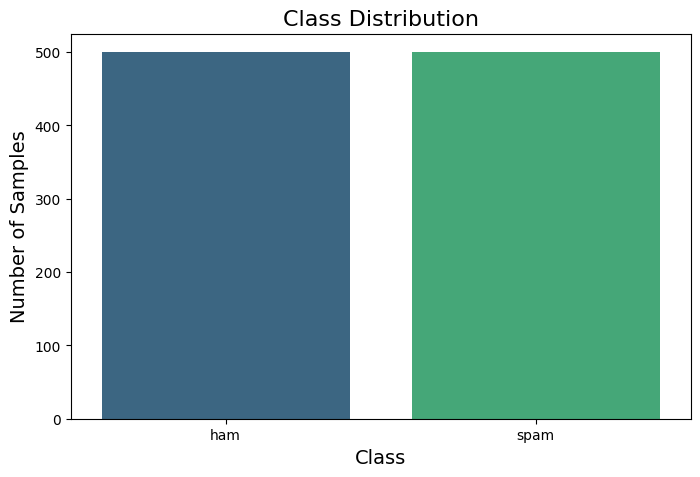

In [ ]:
# Plotting the class distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Class Distribution", fontsize=16)
plt.xlabel("Class", fontsize=14)
plt.ylabel("Number of Samples", fontsize=14)
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Using Regex to create text formats for data preprocessing
import re

# remove URLs from text
def remove_urls(text):
    return re.sub(r'http\S+|www.\S+', '', text)
data['text'] = data['text'].apply(remove_urls)
data.head()


,text,label
0,﻿ممنون آقا سامان.\nمن پارسال اصلا آزاد شرکت نک...,ham
1,﻿سلام آقای کریمی\nبالاخره آزمونارشد تموم شد من...,ham
2,﻿درود بر حاج وحیدی بنده بعنوان یک دکتری تاریخ ...,ham
3,﻿با سلام و احترام\nضمن تقدیر از مسولین محترم ...,ham
4,﻿با سلام اینجانب یک دستگاه خودرو پراید 131 با ...,ham


In [ ]:
# remove email addresses from text
def remove_emails(text):
    return re.sub(r'\S+@\S+\.\S+', '', text)
data['text'] = data['text'].apply(remove_emails)
data.head()


,text,label
0,﻿ممنون آقا سامان.\nمن پارسال اصلا آزاد شرکت نک...,ham
1,﻿سلام آقای کریمی\nبالاخره آزمونارشد تموم شد من...,ham
2,﻿درود بر حاج وحیدی بنده بعنوان یک دکتری تاریخ ...,ham
3,﻿با سلام و احترام\nضمن تقدیر از مسولین محترم ...,ham
4,﻿با سلام اینجانب یک دستگاه خودرو پراید 131 با ...,ham


In [ ]:

# remove phone numbers from text
def remove_phone_numbers(text):
    return re.sub(r'\b\d{10,}\b', '', text)
data['text'] = data['text'].apply(remove_phone_numbers)
data.head()


,text,label
0,﻿ممنون آقا سامان.\nمن پارسال اصلا آزاد شرکت نک...,ham
1,﻿سلام آقای کریمی\nبالاخره آزمونارشد تموم شد من...,ham
2,﻿درود بر حاج وحیدی بنده بعنوان یک دکتری تاریخ ...,ham
3,﻿با سلام و احترام\nضمن تقدیر از مسولین محترم ...,ham
4,﻿با سلام اینجانب یک دستگاه خودرو پراید 131 با ...,ham


In [ ]:
# reduce repeated characters
def reduce_repeated_characters(text):
    return re.sub(r'(.)\1+', r'\1', text)
data['text'] = data['text'].apply(reduce_repeated_characters)
data.head()


,text,label
0,﻿منون آقا سامان.\nمن پارسال اصلا آزاد شرکت نکر...,ham
1,﻿سلام آقای کریمی\nبالاخره آزمونارشد تموم شد من...,ham
2,﻿درود بر حاج وحیدی بنده بعنوان یک دکتری تاریخ ...,ham
3,﻿با سلام و احترام\nضمن تقدیر از مسولین محترم س...,ham
4,﻿با سلام اینجانب یک دستگاه خودرو پراید 131 با ...,ham


In [ ]:
#persian stop words
persian_stop_words = ['و', 'به', 'از', 'که', 'را']

#remove stop words
def remove_stop_words(text):
    return ' '.join(word for word in text.split() if word not in persian_stop_words)

data['text'] = data['text'].apply(remove_stop_words)
data.head()


,text,label
0,﻿منون آقا سامان. من پارسال اصلا آزاد شرکت نکرد...,ham
1,﻿سلام آقای کریمی بالاخره آزمونارشد تموم شد من ...,ham
2,﻿درود بر حاج وحیدی بنده بعنوان یک دکتری تاریخ ...,ham
3,﻿با سلام احترام ضمن تقدیر مسولین محترم سایت تا...,ham
4,﻿با سلام اینجانب یک دستگاه خودرو پراید 131 با ...,ham


In [ ]:
!pip install transformers

In [ ]:
from transformers import AutoTokenizer
# Load the ParsBERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("HooshvareLab/bert-fa-base-uncased")


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/440 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.20M [00:00<?, ?B/s]

In [ ]:
# tokenize the text column
def tokenize_text(text):
    return tokenizer.encode(text, add_special_tokens=True)

data['tokenized_text'] = data['text'].apply(tokenize_text)
data[['text', 'tokenized_text']].head()


,text,tokenized_text
0,﻿منون آقا سامان. من پارسال اصلا آزاد شرکت نکرد...,"[2, 63866, 7664, 9819, 1012, 2842, 14104, 5899..."
1,﻿سلام آقای کریمی بالاخره آزمونارشد تموم شد من ...,"[2, 4285, 4033, 10407, 7637, 6191, 42075, 3192..."
2,﻿درود بر حاج وحیدی بنده بعنوان یک دکتری تاریخ ...,"[2, 17960, 2801, 7343, 37605, 7912, 9355, 2829..."
3,﻿با سلام احترام ضمن تقدیر مسولین محترم سایت تا...,"[2, 2799, 4285, 6755, 4744, 8418, 45904, 8496,..."
4,﻿با سلام اینجانب یک دستگاه خودرو پراید 131 با ...,"[2, 2799, 4285, 19622, 2829, 3698, 3379, 13814..."


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

#padding
max_length = 32
data['padded_text'] = pad_sequences(data['tokenized_text'], maxlen=max_length, padding='post', truncating='post').tolist()
data[['text', 'padded_text']].head()


,text,padded_text
0,﻿منون آقا سامان. من پارسال اصلا آزاد شرکت نکرد...,"[2, 63866, 7664, 9819, 1012, 2842, 14104, 5899..."
1,﻿سلام آقای کریمی بالاخره آزمونارشد تموم شد من ...,"[2, 4285, 4033, 10407, 7637, 6191, 42075, 3192..."
2,﻿درود بر حاج وحیدی بنده بعنوان یک دکتری تاریخ ...,"[2, 17960, 2801, 7343, 37605, 7912, 9355, 2829..."
3,﻿با سلام احترام ضمن تقدیر مسولین محترم سایت تا...,"[2, 2799, 4285, 6755, 4744, 8418, 45904, 8496,..."
4,﻿با سلام اینجانب یک دستگاه خودرو پراید 131 با ...,"[2, 2799, 4285, 19622, 2829, 3698, 3379, 13814..."


In [ ]:
from transformers import TFAutoModel

# Load the pretrained ParsBERT model
parsbert_model = TFAutoModel.from_pretrained("HooshvareLab/bert-fa-base-uncased")


tf_model.h5:   0%|          | 0.00/963M [00:00<?, ?B/s]

Some layers from the model checkpoint at HooshvareLab/bert-fa-base-uncased were not used when initializing TFBertModel: ['mlm___cls', 'nsp___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertModel were initialized from the model checkpoint at HooshvareLab/bert-fa-base-uncased.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.


In [ ]:
import tensorflow as tf
import numpy as np

# tensors for ParsBERT
input_ids = tf.convert_to_tensor(data['padded_text'].tolist())
attention_mask = tf.convert_to_tensor([[1] * max_length] * len(data))
# embeddings using ParsBERT
outputs = parsbert_model(input_ids=input_ids, attention_mask=attention_mask)
embeddings = outputs.last_hidden_state.numpy()

print("Embeddings shape:", embeddings.shape)


Embeddings shape: (1000, 32, 768)


In [ ]:
from sklearn.decomposition import PCA

# reduce dimensions using PCA
pca = PCA(n_components=120)
reduced_embeddings = pca.fit_transform(embeddings.reshape(embeddings.shape[0], -1))

print("Reduced embeddings shape:", reduced_embeddings.shape)


Reduced embeddings shape: (1000, 120)


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode the labels
label_encoder = LabelEncoder()
data['label_encoded'] = label_encoder.fit_transform(data['label']) # binary

# Splitting the dataset into 70% training and 30% testing
X = reduced_embeddings
y = data['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")


Training set size: 700
Test set size: 300


In [ ]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Reshape, Dense, BatchNormalization, Dropout, LSTM


In [ ]:


def create_cnn_lstm_model(optimizer, learning_rate):

    model = Sequential([
      # CNN layers
      Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(120, 1)),
      MaxPooling1D(pool_size=2),
      Flatten(),

      Dense(128, activation='relu'),  # Add an dense layer to match LSTM input size
      Reshape((64, 2)),

      # LSTM layer
      LSTM(32, return_sequences=False),
      Dropout(0.3),
      Dense(128, activation='relu'),
      BatchNormalization(),
      Dropout(0.5),
      Dense(64, activation='relu'),
      BatchNormalization(),
      Dropout(0.5),
      Dense(1, activation='sigmoid')  # Binary classification
    ])

    # Compile the model
    opt = optimizer(learning_rate=learning_rate)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

    return model


In [ ]:

X_train_reshaped = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_reshaped = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"Training set reshaped to: {X_train_reshaped.shape}")
print(f"Test set reshaped to: {X_test_reshaped.shape}")


Training set reshaped to: (700, 120, 1)
Test set reshaped to: (300, 120, 1)


In [ ]:

import itertools

from tensorflow.keras.callbacks import EarlyStopping

# Define hyperparameters
batch_sizes = [8, 16, 64]
learning_rates = [0.001, 0.0001]
optimizers = [Adam, SGD]

param_combinations = list(itertools.product(batch_sizes, learning_rates, optimizers))

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

best_model = None
best_accuracy = 0
best_params = None

for batch_size, learning_rate, optimizer in param_combinations:
    print(f"Testing batch_size={batch_size}, learning_rate={learning_rate}, optimizer={optimizer.__name__}")
    model = create_cnn_lstm_model(optimizer, learning_rate)

    # Train the model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=50,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=1
    )

    # Evaluate model
    test_accuracy = model.evaluate(X_test, y_test, verbose=0)[1]

    if test_accuracy > best_accuracy:
        best_model = model
        best_accuracy = test_accuracy
        best_params = (batch_size, learning_rate, optimizer.__name__)
        print(f"New best model found")

print(f"Best parameters: batch_size={best_params[0]}, learning_rate={best_params[1]}, optimizer={best_params[2]}")



Testing batch_size=8, learning_rate=0.001, optimizer=Adam
Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.4868 - loss: 0.7925 - val_accuracy: 0.5733 - val_loss: 0.6719
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.7687 - loss: 0.5113 - val_accuracy: 0.8867 - val_loss: 0.4820
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9051 - loss: 0.2742 - val_accuracy: 0.8600 - val_loss: 0.4012
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9166 - loss: 0.2285 - val_accuracy: 0.9067 - val_loss: 0.3202
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9015 - loss: 0.2555 - val_accuracy: 0.9267 - val_loss: 0.2411
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9588 - loss: 0.1332 - val_accuracy: 0.9233 - val_loss: 0.1950
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9672 - loss: 0.0953 - val_accuracy: 0.9433 - val_loss: 0.1525
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step -

In [ ]:
# Evaluate the best model on the test set
test_loss, test_accuracy = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy}")


Test Accuracy: 0.9666666388511658


In [ ]:
# the best model
model = Sequential([
    # CNN layers
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(120, 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Reshape((64, 2)),
    # LSTM layer
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
# Print the model summary to verify the architecture
model.summary()


Model: "sequential_83"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_95 (Conv1D)                   │ (None, 118, 32)             │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_95 (MaxPooling1D)      │ (None, 59, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_47 (Flatten)                 │ (None, 1888)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_222 (Dense)                    │ (None, 128)                 │         241,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_43 (Reshape)                 │ (None, 64, 2)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_81 (LSTM)                       │ (None, 32)                  │           4,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_171 (Dropout)                │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_223 (Dense)                    │ (None, 128)                 │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_128              │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_172 (Dropout)                │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_224 (Dense)                    │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_129              │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_173 (Dropout)                │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_225 (Dense)                    │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 259,713 (1014.50 KB)

 Trainable params: 259,329 (1013.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:

from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,  # Max epochs
    batch_size=8,  # Best batch size
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 79ms/step - accuracy: 0.5044 - loss: 1.0405 - val_accuracy: 0.5000 - val_loss: 0.6901
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.4389 - loss: 1.0196 - val_accuracy: 0.5000 - val_loss: 0.6990
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.5383 - loss: 0.8554 - val_accuracy: 0.5000 - val_loss: 0.7018
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5081 - loss: 0.8390 - val_accuracy: 0.5967 - val_loss: 0.6788
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.5533 - loss: 0.7891 - val_accuracy: 0.5033 - val_loss: 0.7241
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.6155 - loss: 0.7007 - val_accuracy: 0.7567 - val_loss: 0.4674
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.7162 - loss: 0.5737 - val_accuracy: 0.8500 - val_loss: 0.3625
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.8129 - loss: 0.4598 - val_accuracy: 0.9067 - 

In [ ]:
# Cell 27
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")


Test Loss: 0.14780092239379883
Test Accuracy: 0.95333331823349


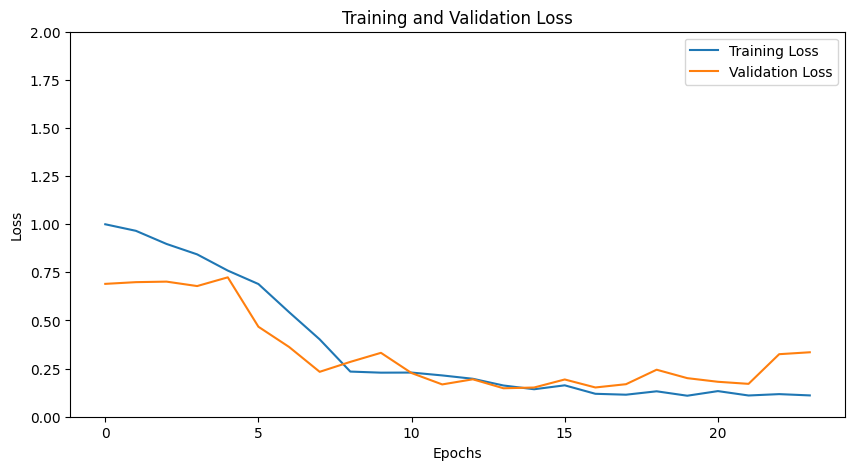

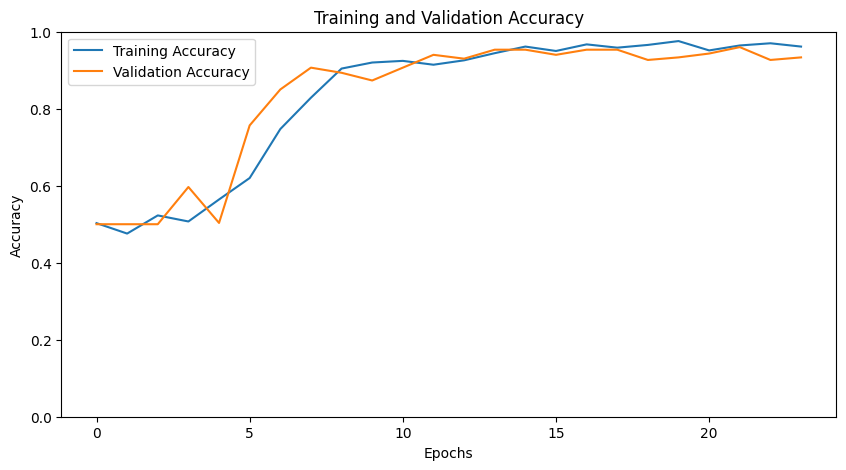

In [ ]:

import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(0, 2)
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend()
plt.show()


In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Create the CNN model
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(120, 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification
])

cnn_optimizer = Adam(learning_rate=0.001)
cnn_model.compile(optimizer=cnn_optimizer, loss='binary_crossentropy', metrics=['accuracy'])

cnn_model.summary()


Model: "sequential_77"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_89 (Conv1D)                   │ (None, 118, 64)             │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_89 (MaxPooling1D)      │ (None, 59, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_41 (Flatten)                 │ (None, 3776)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_199 (Dense)                    │ (None, 128)                 │         483,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_116              │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_154 (Dropout)                │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_200 (Dense)                    │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_117              │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_155 (Dropout)                │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_201 (Dense)                    │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 492,801 (1.88 MB)

 Trainable params: 492,417 (1.88 MB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_cnn = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_cnn = cnn_model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_test_reshaped, y_test),
    epochs=50,
    batch_size=8,
    callbacks=[early_stopping_cnn],
    verbose=1
)


Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.5758 - loss: 0.9100 - val_accuracy: 0.5833 - val_loss: 1.0587
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8074 - loss: 0.4242 - val_accuracy: 0.8067 - val_loss: 0.4424
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9069 - loss: 0.2796 - val_accuracy: 0.9267 - val_loss: 0.2257
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8428 - loss: 0.3479 - val_accuracy: 0.9200 - val_loss: 0.2437
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8831 - loss: 0.2546 - val_accuracy: 0.9300 - val_loss: 0.1835
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9009 - loss: 0.2361 - val_accuracy: 0.9400 - val_loss: 0.1810
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9014 - loss: 0.2631 - val_accuracy: 0.9467 - val_loss: 0.1704
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9304 - loss: 0.1892 - val_accuracy: 0.9333 - v

In [ ]:

cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"CNN Model Test Loss: {cnn_test_loss}")
print(f"CNN Model Test Accuracy: {cnn_test_accuracy}")


CNN Model Test Loss: 0.11075156927108765
CNN Model Test Accuracy: 0.9633333086967468


In [ ]:

from tensorflow.keras.layers import LSTM

# Create the LSTM model
lstm_model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(120, 1)),
    Dropout(0.5),
    LSTM(64),
    Dropout(0.5),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification
])

lstm_optimizer = Adam(learning_rate=0.001)
lstm_model.compile(optimizer=lstm_optimizer, loss='binary_crossentropy', metrics=['accuracy'])

lstm_model.summary()


Model: "sequential_85"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_84 (LSTM)                       │ (None, 120, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_177 (Dropout)                │ (None, 120, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_85 (LSTM)                       │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_178 (Dropout)                │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_228 (Dense)                    │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_131              │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_179 (Dropout)                │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_229 (Dense)                    │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 120,449 (470.50 KB)

 Trainable params: 120,321 (470.00 KB)

 Non-trainable params: 128 (512.00 B)

In [ ]:

early_stopping_lstm = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the LSTM model
history_lstm = lstm_model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_test_reshaped, y_test),
    epochs=50,
    batch_size=8,
    callbacks=[early_stopping_lstm],
    verbose=1
)


Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 21s 153ms/step - accuracy: 0.4694 - loss: 0.9674 - val_accuracy: 0.5033 - val_loss: 0.6916
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 137ms/step - accuracy: 0.5200 - loss: 0.8327 - val_accuracy: 0.5000 - val_loss: 0.6901
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 21s 147ms/step - accuracy: 0.5330 - loss: 0.7975 - val_accuracy: 0.5000 - val_loss: 0.7028
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 145ms/step - accuracy: 0.4780 - loss: 0.8396 - val_accuracy: 0.5300 - val_loss: 0.6920
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 21s 146ms/step - accuracy: 0.5259 - loss: 0.7820 - val_accuracy: 0.5000 - val_loss: 0.7035
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 22s 160ms/step - accuracy: 0.4576 - loss: 0.7961 - val_accuracy: 0.4900 - val_loss: 0.6967
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 146ms/step - accuracy: 0.4915 - loss: 0.7392 - val_accuracy: 0.5033 - val_loss: 0.6933
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.4738 - loss: 0.7482 - val_accu

In [ ]:

lstm_test_loss, lstm_test_accuracy = lstm_model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"LSTM Model Test Loss: {lstm_test_loss}")
print(f"LSTM Model Test Accuracy: {lstm_test_accuracy}")


LSTM Model Test Loss: 0.6900575757026672
LSTM Model Test Accuracy: 0.5


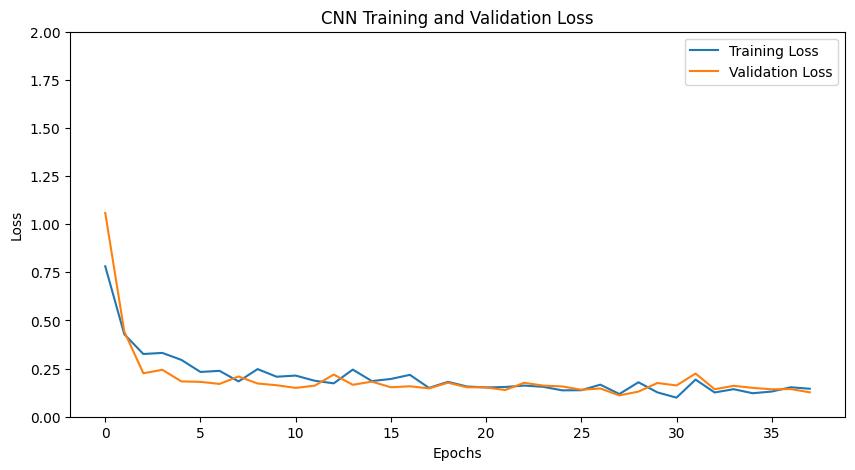

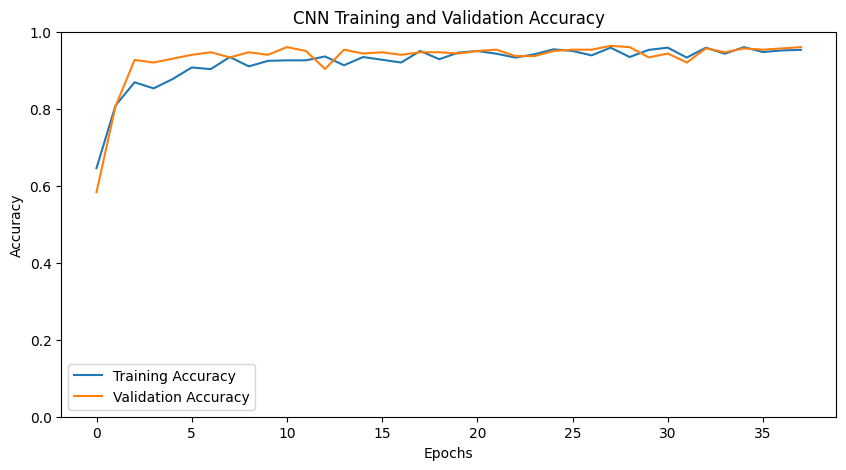

In [ ]:

import matplotlib.pyplot as plt

# CNN Loss plot
plt.figure(figsize=(10, 5))
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(0,2)
plt.legend()
plt.show()

# CNN Accuracy plot
plt.figure(figsize=(10, 5))
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.legend()
plt.show()


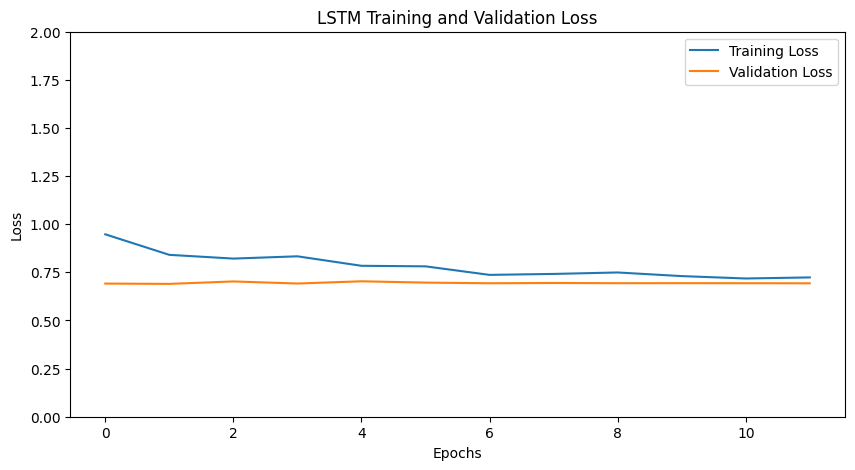

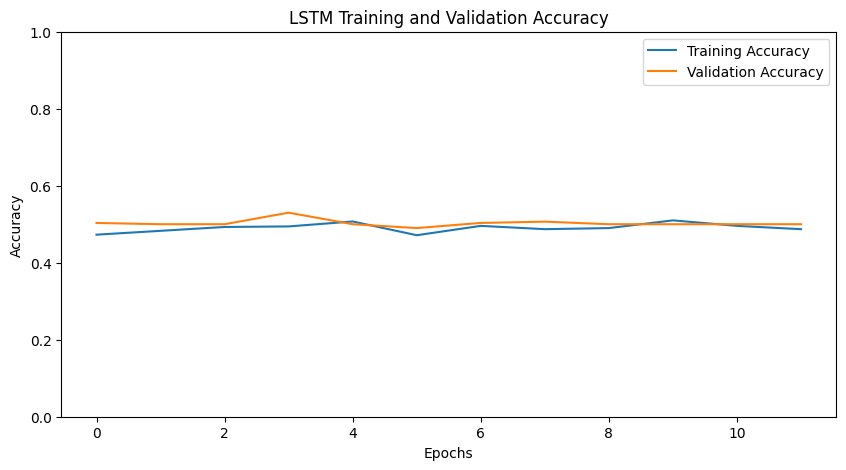

In [ ]:

# LSTM Loss plot
plt.figure(figsize=(10, 5))
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(0,2)
plt.legend()
plt.show()

# LSTM Accuracy plot
plt.figure(figsize=(10, 5))
plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.legend()
plt.show()


In [ ]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return accuracy, precision, recall, f1


In [ ]:
# CNN-LSTM Predictions
cnn_lstm_model = model
cnn_lstm_predictions = (cnn_lstm_model.predict(X_test_reshaped) > 0.5).astype(int)
# CNN Predictions
cnn_predictions = (cnn_model.predict(X_test_reshaped) > 0.5).astype(int)
# LSTM Predictions
lstm_predictions = (lstm_model.predict(X_test_reshaped) > 0.5).astype(int)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step


In [ ]:

# CNN-LSTM Metrics
cnn_lstm_accuracy, cnn_lstm_precision, cnn_lstm_recall, cnn_lstm_f1 = calculate_metrics(y_test, cnn_lstm_predictions)

# CNN Metrics
cnn_accuracy, cnn_precision, cnn_recall, cnn_f1 = calculate_metrics(y_test, cnn_predictions)

# LSTM Metrics
lstm_accuracy, lstm_precision, lstm_recall, lstm_f1 = calculate_metrics(y_test, lstm_predictions)


In [ ]:

import pandas as pd

metrics_table = pd.DataFrame({
    'Model': ['CNN-LSTM', 'CNN', 'LSTM'],
    'Accuracy': [cnn_lstm_accuracy, cnn_accuracy, lstm_accuracy],
    'Precision': [cnn_lstm_precision, cnn_precision, lstm_precision],
    'Recall': [cnn_lstm_recall, cnn_recall, lstm_recall],
    'F1-Score': [cnn_lstm_f1, cnn_f1, lstm_f1]
})

print(metrics_table)


      Model  Accuracy  Precision    Recall  F1-Score
0  CNN-LSTM  0.953333   0.965753  0.940000  0.952703
1       CNN  0.963333   0.972789  0.953333  0.962963
2      LSTM  0.500000   0.500000  0.053333  0.096386


In [ ]:

from sklearn.feature_extraction.text import CountVectorizer
=
vectorizer = CountVectorizer(max_features=5000)  # Limit to 5000 features
X_bow = vectorizer.fit_transform(data['text']).toarray() s

print(f"Shape of Bag of Words features: {X_bow.shape}")


Shape of Bag of Words features: (1000, 5000)


In [ ]:

from sklearn.model_selection import train_test_split

X_train_bow, X_test_bow, y_train_bow, y_test_bow = train_test_split(X_bow, y, test_size=0.3, random_state=42)

print(f"Training set size: {X_train_bow.shape}")
print(f"Test set size: {X_test_bow.shape}")


Training set size: (700, 5000)
Test set size: (300, 5000)


In [ ]:

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(probability=True),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

bow_results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_bow, y_train_bow)
    y_pred = model.predict(X_test_bow)

    accuracy, precision, recall, f1 = calculate_metrics(y_test_bow, y_pred)
    bow_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })


Training Naive Bayes...
Training Logistic Regression...
Training SVM...
Training Random Forest...


In [ ]:

bow_results_df = pd.DataFrame(bow_results)

final_metrics_table = pd.concat([metrics_table, bow_results_df], ignore_index=True)
print(final_metrics_table)


                 Model  Accuracy  Precision    Recall  F1-Score
0             CNN-LSTM  0.953333   0.965753  0.940000  0.952703
1                  CNN  0.963333   0.972789  0.953333  0.962963
2                 LSTM  0.500000   0.500000  0.053333  0.096386
3          Naive Bayes  0.976667   0.993103  0.960000  0.976271
4  Logistic Regression  0.963333   0.979310  0.946667  0.962712
5                  SVM  0.883333   0.913669  0.846667  0.878893
6        Random Forest  0.940000   0.940000  0.940000  0.940000
